# Goal

Let's now check whether the accuracy or execution time changes if FC layer has different values. We're going to test $(fc1, fc2) = (2x, x)$ where $x \in {5,500}$ on GPU.

# Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Data

In [2]:
n_per_clust = 1000
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = [1.8, 2.4]

# images and labels placeholders
images = torch.zeros(2*n_per_clust, 1, img_size, img_size)
labels = torch.zeros(2*n_per_clust)

for i in range(2*1000):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i%2]**2) # every other label is odd or even due to i%2
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)
  labels[i] = i%2

labels = labels[:,None]

# Train/Test Split and Loaders

In [3]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .8)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

# Model

In [4]:
def CreateModel(kernel = (3,2),
                stride = (2,3),
                img = (91,91),
                padding = (1,1),
                conv_1_out = 3,
                conv_2_out = 6,
                pool = (2,2),
                fc_1_out = 50,
                fc_2_out = 20,
                fc_3_out = 1):

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      # Activations
      self.relu = nn.ReLU()
      self.max_pool = nn.MaxPool2d(pool)

      # Conv
      self.conv_1 = nn.Conv2d(1,conv_1_out,kernel,stride,padding)
      self.conv_1_out_width = ((img[1] + 2 * padding[1] - kernel[1]) // stride[1] ) + 1
      self.conv_1_out_height = ((img[0] + 2 * padding[0] - kernel[0]) // stride[0] ) + 1
      self.conv_1_out_width  //= pool[1]
      self.conv_1_out_height //= pool[0]

      self.conv_2 = nn.Conv2d(conv_1_out,conv_2_out,kernel,stride,padding)
      self.conv_2_out_width = ((self.conv_1_out_width + 2 * padding[1] - kernel[1]) // stride[1] ) + 1
      self.conv_2_out_height = ((self.conv_1_out_height + 2 * padding[0] - kernel[0]) // stride[0] ) + 1
      self.conv_2_out_width  //= pool[1]
      self.conv_2_out_height //= pool[0]

      # FCs
      self.fc1 = nn.Linear(self.conv_2_out_width * self.conv_2_out_height * conv_2_out, fc_1_out)
      self.fc2 = nn.Linear(fc_1_out, fc_2_out)
      self.fc3 = nn.Linear(fc_2_out, fc_3_out)

    def forward(self, x):
      conv_1 = self.relu(self.conv_1(x))
      x = self.max_pool(conv_1)

      conv_2 = self.relu(self.conv_2(x))
      x = self.max_pool(conv_2)

      x = torch.flatten(x, 1)
      x = self.relu(self.fc1(x))
      x = self.relu(self.fc2(x))
      x = self.fc3(x)

      return x, conv_1, conv_2

  net = CreateNet()
  loss_fn = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [5]:
net, loss_fn, optimizer = CreateModel()
X, y = next(iter(train_dataloader))
y_hat, feature_map_1, feature_map_2 = net(X)
loss = loss_fn(y_hat, y)
loss

tensor(0.6966, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

# Train

In [6]:
def RunModel(fc_1_out, fc_2_out):

  epochs = 20

  # create a new model
  net, loss_fn, optimizer = CreateModel(fc_1_out = fc_1_out,
                                        fc_2_out = fc_2_out)

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  net.to(device)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      y_hat = net(X)[0]
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc = ((y_hat > 0).float() == y).float().mean().item()

      # batch loss and acc
      batch_losses.append(loss.item())
      batch_accs.append(batch_acc)

    # losses
    train_losses[epoch] = np.mean(batch_losses)
    train_accs[epoch] = 100 * np.mean(batch_accs)

    # test acc
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      X = X.to(device)
      y = y.to(device)
      y_hat = net(X)[0]
      loss = loss_fn(y_hat, y)

    test_losses[epoch] = loss.item()
    test_acc = 100 * ((y_hat > 0).float() == y).float().mean().item()
    test_accs[epoch] = test_acc

    # print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs

# Test Model with Time Count

In [7]:
import time

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [8]:
start = time.perf_counter()
torch.cuda.synchronize()

x = 10

train_losses, test_losses, train_accs, test_accs = RunModel(fc_1_out = 2*x,
                                                            fc_2_out = x)

torch.cuda.synchronize()
end = time.perf_counter()
final = end - start

print(f'\nTotal runtime: {final:.2f}')


Total runtime: 3.47


Let's pack it up in function

In [9]:
def time_acc(fn, *args, **kwargs):
    torch.cuda.synchronize()
    start = time.perf_counter()

    train_losses, test_losses, train_accs, test_accs = fn(*args, **kwargs)

    torch.cuda.synchronize()
    end = time.perf_counter()

    runtime = end - start
    test_acc = test_accs[-1].item()

    return runtime, test_acc


In [10]:
x = 10
time_acc(RunModel,
         fc_1_out=2*x,
         fc_2_out=x)

(2.058201867000008, 99.81249237060547)

# Experiment

In [12]:
xs = np.arange(5,520,20)
N_RUNS = 5
times = np.zeros(len(xs))
accs = np.zeros(len(xs))
xs

array([  5,  25,  45,  65,  85, 105, 125, 145, 165, 185, 205, 225, 245,
       265, 285, 305, 325, 345, 365, 385, 405, 425, 445, 465, 485, 505])

In [13]:
for i, x in enumerate(xs):
    print(f'=== x = {x} ===')

    run_times = []
    run_accs  = []

    for r in range(N_RUNS):
        torch.cuda.empty_cache()

        t, acc = time_acc(
            RunModel,
            fc_1_out=2*x,
            fc_2_out=x
        )

        run_times.append(t)
        run_accs.append(acc)

        print(f'  run {r+1}/{N_RUNS}: time = {t:.3f}s | acc = {acc:.2f}%')

    times[i] = np.mean(run_times)
    accs[i]  = np.mean(run_accs)

    print(f'  AVG: time = {times[i]:.3f}s | acc = {accs[i]:.2f}%\n')

=== x = 5 ===
  run 1/5: time = 1.889s | acc = 100.00%
  run 2/5: time = 1.889s | acc = 49.50%
  run 3/5: time = 2.124s | acc = 99.50%
  run 4/5: time = 1.966s | acc = 99.38%
  run 5/5: time = 1.913s | acc = 93.31%
  AVG: time = 1.956s | acc = 88.34%

=== x = 25 ===
  run 1/5: time = 2.090s | acc = 99.94%
  run 2/5: time = 1.914s | acc = 98.38%
  run 3/5: time = 1.920s | acc = 99.62%
  run 4/5: time = 2.120s | acc = 100.00%
  run 5/5: time = 1.918s | acc = 99.56%
  AVG: time = 1.992s | acc = 99.50%

=== x = 45 ===
  run 1/5: time = 1.969s | acc = 100.00%
  run 2/5: time = 2.143s | acc = 99.94%
  run 3/5: time = 1.953s | acc = 99.75%
  run 4/5: time = 1.924s | acc = 99.94%
  run 5/5: time = 2.049s | acc = 100.00%
  AVG: time = 2.007s | acc = 99.92%

=== x = 65 ===
  run 1/5: time = 1.920s | acc = 100.00%
  run 2/5: time = 1.911s | acc = 99.19%
  run 3/5: time = 2.079s | acc = 99.88%
  run 4/5: time = 1.896s | acc = 99.75%
  run 5/5: time = 1.916s | acc = 99.81%
  AVG: time = 1.945s | ac

# Plots

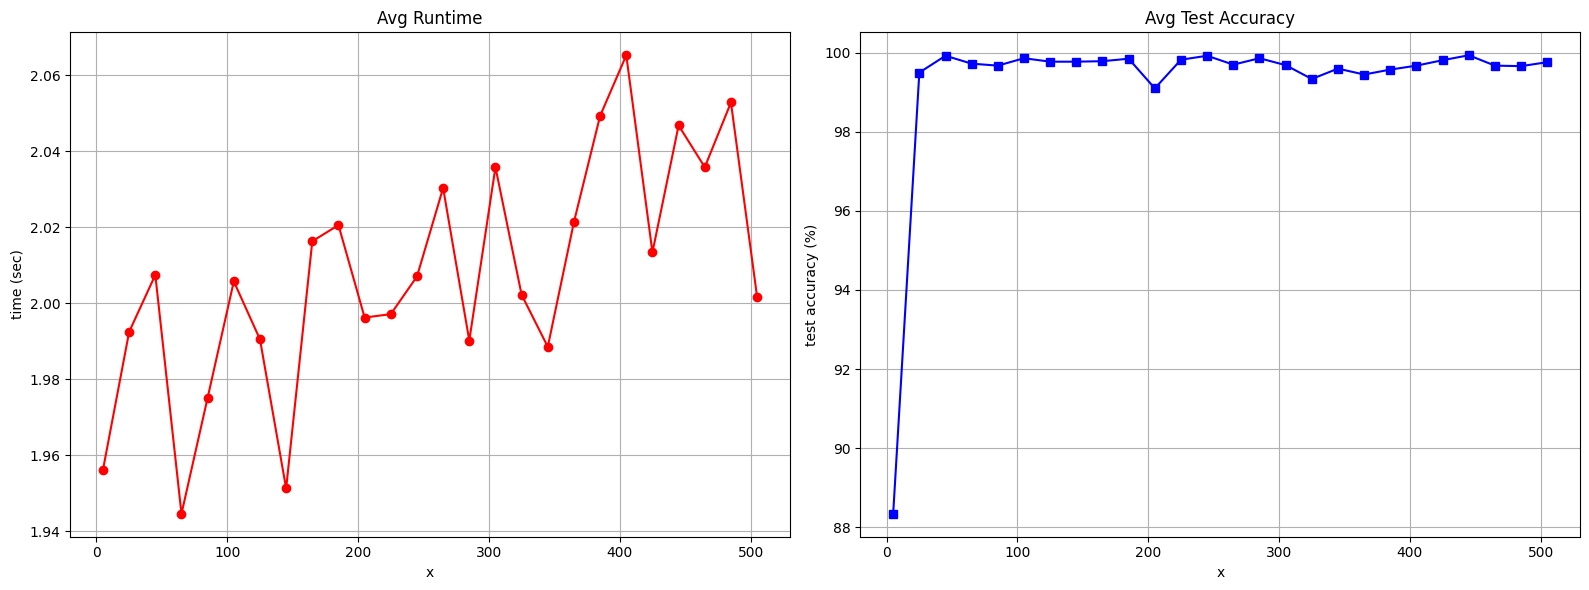

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# TIME
ax1.plot(xs, times, '-ro')
ax1.set_xlabel('x')
ax1.set_ylabel('time (sec)')
ax1.set_title('Avg Runtime')
ax1.grid(True)

# ACC
ax2.plot(xs, accs, '-bs')
ax2.set_xlabel('x')
ax2.set_ylabel('test accuracy (%)')
ax2.set_title('Avg Test Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()


# Conclusion

Adding more complexity to the model doesn't increase accuracy or decrease execution time, i.e. we shouldn't add redundant complexity.